# TNM112 -- Lab 3 -- Exploring GANs

### Data generation
Data genereated and plotted via "data_generator.py".

(MNIST, CIFAR10)

Data specification:
	Dataset type:           None
	Number of channels:     1
	Training data shape:    (60000, 28, 28, 1)


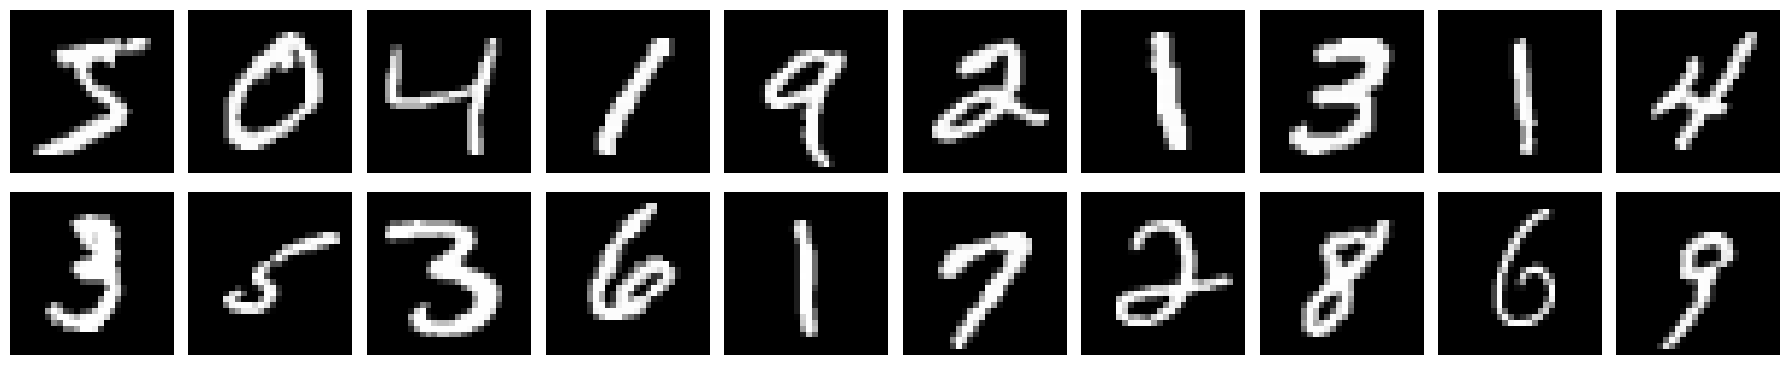

In [10]:
import data_generator

data = data_generator.DataGenerator(verbose=True)
train_images = data.generate(dataset='mnist')
data.plot(xx=10, yy=2)

### GAN
...

In [9]:
import os
import numpy as np
import time
import matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Flatten, Reshape, Conv2D, UpSampling2D, LeakyReLU, Dropout, BatchNormalization
from tensorflow.keras.optimizers import RMSprop

# --- Configuration & Hyperparameters ---
LATENT_DIM = 100
IMG_ROWS, IMG_COLS, IMG_CHANNELS = 28, 28, 1
SAVE_DIR = "images"

# Create directory if it doesn't exist
if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

# --- Data Loading ---
(x_train, _), (_, _) = mnist.load_data()
x_train = x_train.reshape(x_train.shape[0], IMG_ROWS, IMG_COLS, IMG_CHANNELS).astype('float32')
x_train /= 255

# --- Model Definitions ---
def generator_model():
    depth = 256
    dim = 7
    model = Sequential([
        Dense(dim * dim * depth, input_dim=LATENT_DIM),
        BatchNormalization(momentum=0.9),
        Activation('relu'),
        Reshape((dim, dim, depth)),
        Dropout(0.4),

        UpSampling2D(),
        Conv2D(int(depth/2), 5, padding='same'),
        BatchNormalization(momentum=0.9),
        Activation('relu'),

        UpSampling2D(),
        Conv2D(int(depth/4), 5, padding='same'),
        BatchNormalization(momentum=0.9),
        Activation('relu'),

        Conv2D(int(depth/8), 5, padding='same'),
        BatchNormalization(momentum=0.9),
        Activation('relu'),

        Conv2D(1, 5, padding='same'),
        Activation('sigmoid')
    ], name="Generator")
    return model

def discriminator_model():
    depth = 64
    input_shape = (IMG_ROWS, IMG_COLS, IMG_CHANNELS)
    model = Sequential([
        Conv2D(depth, 5, strides=2, input_shape=input_shape, padding='same'),
        LeakyReLU(alpha=0.2),
        Dropout(0.4),

        Conv2D(depth*2, 5, strides=2, padding='same'),
        LeakyReLU(alpha=0.2),
        Dropout(0.4),

        Conv2D(depth*4, 5, strides=2, padding='same'),
        LeakyReLU(alpha=0.2),
        Dropout(0.4),

        Conv2D(depth*8, 5, strides=1, padding='same'),
        LeakyReLU(alpha=0.2),
        Dropout(0.4),

        Flatten(),
        Dense(1),
        Activation('sigmoid')
    ], name="Discriminator")
    return model

# --- Compile Models ---
# 1. Build & Compile Discriminator
discriminator = discriminator_model()
discriminator.compile(loss='binary_crossentropy', 
                      optimizer=RMSprop(learning_rate=0.0002), 
                      metrics=['accuracy'])

# 2. Build Generator
generator = generator_model()

# 3. Build & Compile Adversarial Model (Generator + Frozen Discriminator)
def adversarial_model(gen, disc):
    model = Sequential()
    model.add(gen)
    disc.trainable = False  # Freeze D for G training
    model.add(disc)
    model.compile(loss='binary_crossentropy', 
                  optimizer=RMSprop(learning_rate=0.0001), 
                  metrics=['accuracy'])
    disc.trainable = True # Unfreeze for D training
    return model

adversarial = adversarial_model(generator, discriminator)

# --- Helper Functions ---
def plot_images(saveToFile=False, samples=16, noise=None, epoch=0):
    if noise is None:
        noise = np.random.uniform(-1.0, 1.0, size=[samples, LATENT_DIM])
    
    images = generator.predict(noise)
    plt.figure(figsize=(10,10))
    for i in range(images.shape[0]):
        plt.subplot(4, 4, i+1)
        image = images[i, :, :, :].reshape(IMG_ROWS, IMG_COLS)
        plt.imshow(image, cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    
    if saveToFile:
        filename = os.path.join(SAVE_DIR, f"mnist_{epoch}.png")
        plt.savefig(filename)
        plt.close('all')
    else:
        plt.show()

# --- Training Loop ---
def train(train_epochs=1000, batch_size=32, save_interval=100):
    # Static noise for consistent visual tracking of progress
    noise_input = np.random.uniform(-1.0, 1.0, size=[16, LATENT_DIM])
    
    # Save the initial noise state (Epoch 0)
    plot_images(saveToFile=True, noise=noise_input, epoch=0)

    for epoch in range(train_epochs):
        # 1. Train Discriminator
        idx = np.random.randint(0, x_train.shape[0], size=batch_size)
        images_real = x_train[idx]
        
        noise = np.random.uniform(-1.0, 1.0, size=[batch_size, LATENT_DIM])
        images_fake = generator.predict(noise)
        
        x = np.concatenate((images_real, images_fake))
        y = np.ones([2*batch_size, 1])
        y[batch_size:, :] = 0
        d_loss = discriminator.train_on_batch(x, y)

        # 2. Train Generator (Adversarial)
        y_gen = np.ones([batch_size, 1])
        a_loss = adversarial.train_on_batch(noise, y_gen)
        
        # Logging
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"{epoch+1}: [D loss: {d_loss[0]:.4f}, acc: {d_loss[1]:.4f}] [A loss: {a_loss[0]:.4f}, acc: {a_loss[1]:.4f}]")
        
        # Periodic Saving
        if save_interval > 0 and (epoch + 1) % save_interval == 0:
            plot_images(saveToFile=True, noise=noise_input, epoch=epoch+1)

# --- Timer Utility ---
class ElapsedTimer:
    def __init__(self): self.start = time.time()
    def elapsed_time(self):
        sec = time.time() - self.start
        if sec < 60: t = f"{sec:.2f} sec"
        elif sec < 3600: t = f"{sec/60:.2f} min"
        else: t = f"{sec/3600:.2f} hr"
        print(f"Elapsed: {t}")

# --- Execute ---
timer = ElapsedTimer()
train(train_epochs=2000, batch_size=32, save_interval=100)
timer.elapsed_time()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1: [D loss: 0.6936, acc: 0.5312] [A loss: 0.7413, acc: 0.0000]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
10: [D loss: 0.6639, acc: 0.5031] [A loss: 0.6283, acc: 0.8969]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
20: [D loss: 0.5301, acc: 0.6266] [A loss: 0.4181, acc: 0.9484]
1/1 ━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
0: [D loss: 0.692096, acc: 0.531250]  [A loss: 0.711386, acc: 0.000000]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1: [D loss: 0.690499, acc: 0.515625]  [A loss: 0.701091, acc: 0.312500]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
2: [D loss: 0.688720, acc: 0.510417]  [A loss: 0.695072, acc: 0.500000]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
3: [D loss: 0.686093, acc: 0.507812]  [A loss: 0.688822, acc: 0.625000]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
4: [D loss: 0.683405, acc: 0.506250]  [A loss: 0.681731, acc: 0.700000]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
5: [D loss: 0.680045, acc: 0.505208]  [A loss: 0.673840, acc: 0.750000]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
6: [D loss: 0.675993, acc: 0.504464]  [A loss: 0.665881, acc: 0.785714]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
7: [D loss: 0.670273, acc: 0.503906]  [A loss: 0.655821, acc: 0.812500]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
8: [D loss: 0.662192, acc: 0.503472]  [A loss: 0.642143, acc: 0.833333]
1/1 ━━━━━

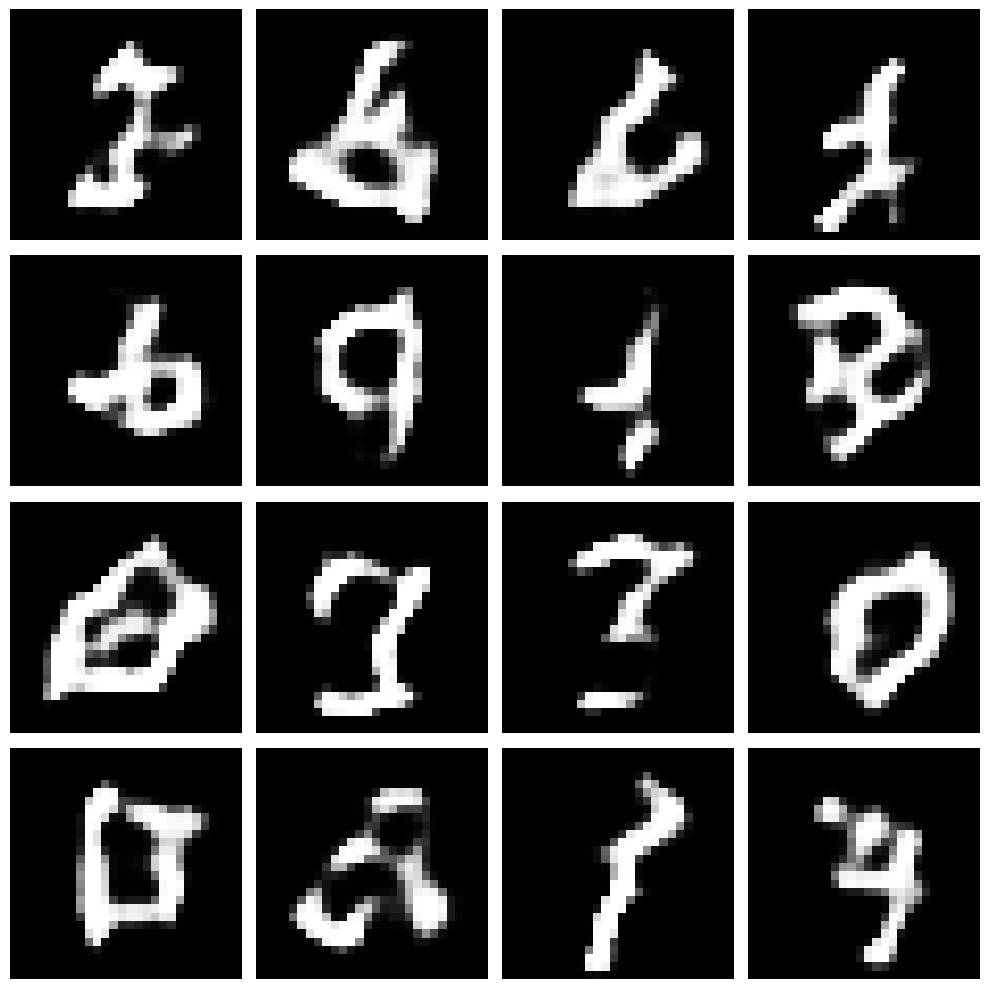

In [4]:
import numpy as np
import time
from keras.datasets import mnist
from keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Flatten, Reshape
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, UpSampling2D
from tensorflow.keras.layers import LeakyReLU, Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam, RMSprop
from matplotlib import pyplot as plt

latent_dim = 100

img_rows, img_cols, img_channels = 28, 28, 1
(x_train, _), (_, _) = mnist.load_data() # 60000 28x28 images
x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, img_channels) # 60000, 28, 28, 1 tensor
x_train = x_train.astype('float32')
x_train /= 255 # values bwtween 0.0—1.0 

def generator_model(): 
    dropout = 0.4
    depth = 256 # 64+64+64+64
    dim = 7
    
    model = Sequential()
    # In: 100
    # Out: dim x dim x depth
    model.add(Dense(dim*dim*depth, input_dim=latent_dim))
    model.add(BatchNormalization(momentum=0.9))
    model.add(Activation('relu'))
    model.add(Reshape((dim, dim, depth)))
    model.add(Dropout(dropout))

    # In: dim x dim x depth
    # Out: 2*dim x 2*dim x depth/2
    model.add(UpSampling2D())
    model.add(Conv2D(int(depth/2), 5, padding='same'))
    model.add(BatchNormalization(momentum=0.9))
    model.add(Activation('relu'))

    model.add(UpSampling2D())
    model.add(Conv2D(int(depth/4), 5, padding='same'))
    model.add(BatchNormalization(momentum=0.9))
    model.add(Activation('relu'))

    model.add(Conv2D(int(depth/8), 5, padding='same'))
    model.add(BatchNormalization(momentum=0.9))
    model.add(Activation('relu'))

    # Out: 28 x 28 x 1 grayscale image [0.0,1.0] per pix
    model.add(Conv2D(1, 5, padding='same'))
    model.add(Activation('sigmoid'))
    
    return model

# (W−F+2P)/S+1
def discriminator_model():
    depth = 64
    dropout = 0.4
    input_shape = (img_rows, img_cols, img_channels)
    
    model = Sequential()
    # In: 28 x 28 x 1, depth = 1
    # Out: 14 x 14 x 1, depth=64
    model.add(Conv2D(depth, 5, strides=2, input_shape=input_shape, padding='same'))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(dropout))

    model.add(Conv2D(depth*2, 5, strides=2, padding='same'))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(dropout))

    model.add(Conv2D(depth*4, 5, strides=2, padding='same'))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(dropout))

    model.add(Conv2D(depth*8, 5, strides=1, padding='same'))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(dropout))

    # Out: 1-dim probability
    model.add(Flatten())
    model.add(Dense(1))
    model.add(Activation('sigmoid'))
    
    return model

discriminator = discriminator_model()
discriminator.compile(loss='binary_crossentropy', 
                      optimizer=RMSprop(learning_rate=0.0002), 
                      metrics=['accuracy'])

generator = generator_model()

def adversarial_model():
    model = Sequential()
    model.add(generator)
    discriminator.trainable = False
    model.add(discriminator)
    model.compile(loss='binary_crossentropy', 
                  optimizer=RMSprop(learning_rate=0.0001), 
                  metrics=['accuracy'])
    discriminator.trainable = True
    return model

adversarial = adversarial_model()

def plot_images(saveToFile=False, fake=True, samples=16, noise=None, epoch=0):
    filename = 'mnist.png'
    if fake:
        if noise is None:
            noise = np.random.uniform(-1.0, 1.0, size=[samples, latent_dim])
        else:
            filename = "mnist_%d.png" % epoch
        images = generator.predict(noise)
    else:
        i = np.random.randint(0, x_train.shape[0], samples)
        images = x_train[i, :, :, :]

    plt.figure(figsize=(10,10))
    for i in range(images.shape[0]):
        plt.subplot(4, 4, i+1)
        image = images[i, :, :, :]
        image = np.reshape(image, [img_rows, img_cols])
        plt.imshow(image, cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    if saveToFile:
        plt.savefig(filename)
        plt.close('all')
    else:
        plt.show()

def train(train_epochs=1000, batch_size=32, save_interval=0):
        noise_input = None
        if save_interval>0:
            noise_input = np.random.uniform(-1.0, 1.0, size=[16, latent_dim])
        for epoch in range(train_epochs):
            
            # ---------------------
            #  Train Discriminator
            # ---------------------
            
            # select a random half of images
            images_train = x_train[np.random.randint(0, x_train.shape[0], size=batch_size), :, :, :] # 32, 28, 28 , 1 tensor
            
            # sample noise and generate a batch of new images
            noise = np.random.uniform(-1.0, 1.0, size=[batch_size, latent_dim]) # 32, 100 matrix of random -1.0—1.0 numbers
            images_fake = generator.predict(noise) # model processes all 32 noise seeds, generate 32 fake images: 32, 28, 28, 1 tensor
            
            # train the discriminator (real classified as ones and generated as zeros)
            x = np.concatenate((images_train, images_fake)) # stack fake and real images togheter to a 64, 28, 28, 1 tensor
            y = np.ones([2*batch_size, 1]) # column of 64 ones
            y[batch_size:, :] = 0 # Keep first 32 labels as 1 (Real), change index 32 to the end to 0 (Fake)
            d_loss = discriminator.train_on_batch(x, y) # The backpropagation step for the discriminator
            # Discriminator looks at x and makes guesses.
            # Compares guesses to labels y
            # Backpropagation: calculates the error (loss) and updates its internal weights to be more accurate next time.
            # Returns d_loss (a list containing the Loss value and the Accuracy).

            # ---------------------
            #  Train Generator
            # ---------------------
            
            # train the generator (wants discriminator to mistake images as real)
            y = np.ones([batch_size, 1]) # column of 32 ones. 
            # Making labels 1 to make generator produce something that results in a '1' (Real) from the Discriminator.
            a_loss = adversarial.train_on_batch(noise, y)
            # 1.  The noise goes into the Generator -> becomes an image.
            # 2.  That image goes into the Discriminator -> becomes a prediction.
            # 3.  discriminator.trainable = False earlier, the Discriminator’s weights stay frozen.
            # 4.  Backpropagation: The error travels backwards through the Discriminator (without changing it) and hits the Generator.
            #     The Generator's weights are then updated to move its output closer to what the Discriminator considers "Real."
            
            log_msg = "%d: [D loss: %f, acc: %f]" % (epoch, d_loss[0], d_loss[1])
            log_msg = "%s  [A loss: %f, acc: %f]" % (log_msg, a_loss[0], a_loss[1])
            print(log_msg)
            if save_interval>0:
                if (epoch+1)%save_interval==0:
                    plot_images(saveToFile=True, samples=noise_input.shape[0],
                                noise=noise_input, epoch=(epoch+1))

class ElapsedTimer(object):
    def __init__(self):
        self.start_time = time.time()
    def elapsed(self,sec):
        if sec < 60:
            return str(sec) + " sec"
        elif sec < (60 * 60):
            return str(sec / 60) + " min"
        else:
            return str(sec / (60 * 60)) + " hr"
    def elapsed_time(self):
        print("Elapsed: %s " % self.elapsed(time.time() - self.start_time))

timer = ElapsedTimer()
train(train_epochs=1000, batch_size=32, save_interval=100) 
timer.elapsed_time()
plot_images(fake=True)
plot_images(fake=False, saveToFile=True)

""" Results (last 5 epochs):

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
995: [D loss: 0.649261, acc: 0.609830]  [A loss: 1.231699, acc: 0.273312]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
996: [D loss: 0.649368, acc: 0.609735]  [A loss: 1.232018, acc: 0.273038]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
997: [D loss: 0.649408, acc: 0.609672]  [A loss: 1.231373, acc: 0.273578]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
998: [D loss: 0.649541, acc: 0.609578]  [A loss: 1.231702, acc: 0.273305]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
999: [D loss: 0.649682, acc: 0.609312]  [A loss: 1.230979, acc: 0.273906]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Elapsed: 12.515962747732798 min 

"""

In [11]:
import os
import numpy as np
import time
import matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Flatten, Reshape, Conv2D, UpSampling2D, LeakyReLU, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# --- Configuration & Hyperparameters ---
LATENT_DIM = 100
IMG_ROWS, IMG_COLS, IMG_CHANNELS = 28, 28, 1
SAVE_DIR = "images_adam_smooth"

# Create directory if it doesn't exist
if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

# --- Data Loading ---
(x_train, _), (_, _) = mnist.load_data()
x_train = x_train.reshape(x_train.shape[0], IMG_ROWS, IMG_COLS, IMG_CHANNELS).astype('float32')
x_train /= 255

# --- Model Definitions ---
def generator_model():
    depth = 256
    dim = 7
    model = Sequential([
        Dense(dim * dim * depth, input_dim=LATENT_DIM),
        BatchNormalization(momentum=0.9),
        Activation('relu'),
        Reshape((dim, dim, depth)),
        Dropout(0.4),

        UpSampling2D(),
        Conv2D(int(depth/2), 5, padding='same'),
        BatchNormalization(momentum=0.9),
        Activation('relu'),

        UpSampling2D(),
        Conv2D(int(depth/4), 5, padding='same'),
        BatchNormalization(momentum=0.9),
        Activation('relu'),

        Conv2D(int(depth/8), 5, padding='same'),
        BatchNormalization(momentum=0.9),
        Activation('relu'),

        Conv2D(1, 5, padding='same'),
        Activation('sigmoid')
    ], name="Generator")
    return model

def discriminator_model():
    depth = 64
    input_shape = (IMG_ROWS, IMG_COLS, IMG_CHANNELS)
    model = Sequential([
        Conv2D(depth, 5, strides=2, input_shape=input_shape, padding='same'),
        LeakyReLU(alpha=0.2),
        Dropout(0.4),

        Conv2D(depth*2, 5, strides=2, padding='same'),
        LeakyReLU(alpha=0.2),
        Dropout(0.4),

        Conv2D(depth*4, 5, strides=2, padding='same'),
        LeakyReLU(alpha=0.2),
        Dropout(0.4),

        Conv2D(depth*8, 5, strides=1, padding='same'),
        LeakyReLU(alpha=0.2),
        Dropout(0.4),

        Flatten(),
        Dense(1),
        Activation('sigmoid')
    ], name="Discriminator")
    return model

# --- Setup with Adam and Label Smoothing ---

# Adam with Beta_1 = 0.5 is the DCGAN standard
opt_d = Adam(learning_rate=0.0002, beta_1=0.5)
opt_a = Adam(learning_rate=0.0001, beta_1=0.5)
    
# --- Compile Models ---
# 1. Build & Compile Discriminator
discriminator = discriminator_model()
discriminator.compile(loss='binary_crossentropy', 
                      optimizer=opt_d, 
                      metrics=['accuracy'])

# 2. Build Generator
generator = generator_model()

# 3. Build & Compile Adversarial Model (Generator + Frozen Discriminator)
def adversarial_model(gen, disc):
    model = Sequential()
    model.add(gen)
    disc.trainable = False  # Freeze D for G training
    model.add(disc)
    model.compile(loss='binary_crossentropy', 
                  optimizer=opt_a, 
                  metrics=['accuracy'])
    disc.trainable = True # Unfreeze for D training
    return model

adversarial = adversarial_model(generator, discriminator)

# --- Helper Functions ---
def plot_images(saveToFile=False, samples=16, noise=None, epoch=0):
    if noise is None:
        noise = np.random.uniform(-1.0, 1.0, size=[samples, LATENT_DIM])
    
    images = generator.predict(noise)
    plt.figure(figsize=(10,10))
    for i in range(images.shape[0]):
        plt.subplot(4, 4, i+1)
        image = images[i, :, :, :].reshape(IMG_ROWS, IMG_COLS)
        plt.imshow(image, cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    
    if saveToFile:
        filename = os.path.join(SAVE_DIR, f"mnist_{epoch}.png")
        plt.savefig(filename)
        plt.close('all')
    else:
        plt.show()

# --- Training Loop ---
def train(train_epochs=1000, batch_size=32, save_interval=100):
    # Static noise for consistent visual tracking of progress
    noise_input = np.random.uniform(-1.0, 1.0, size=[16, LATENT_DIM])
    
    # Save the initial noise state (Epoch 0)
    plot_images(saveToFile=True, noise=noise_input, epoch=0)

    for epoch in range(train_epochs):
        # 1. Train Discriminator
        idx = np.random.randint(0, x_train.shape[0], size=batch_size)
        images_real = x_train[idx]
        
        noise = np.random.uniform(-1.0, 1.0, size=[batch_size, LATENT_DIM])
        images_fake = generator.predict(noise)

        # --- LABEL SMOOTHING APPLIED HERE ---
        y_real = np.ones([batch_size, 1]) * 0.9  # 0.9 instead of 1.0
        y_fake = np.zeros([batch_size, 1])

        # Train separately on real and fake (often more stable than concatenating)
        d_loss_real = discriminator.train_on_batch(images_real, y_real)
        d_loss_fake = discriminator.train_on_batch(images_fake, y_fake)
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

        # 2. Train Generator
        y_gen = np.ones([batch_size, 1]) # Generator still wants to hit 1.0
        a_loss = adversarial.train_on_batch(noise, y_gen)
        
        # Logging
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"{epoch+1}: [D loss: {d_loss[0]:.4f}, acc: {d_loss[1]:.4f}] [A loss: {a_loss[0]:.4f}, acc: {a_loss[1]:.4f}]")
        
        # Periodic Saving
        if save_interval > 0 and (epoch + 1) % save_interval == 0:
            plot_images(saveToFile=True, noise=noise_input, epoch=epoch+1)

# --- Timer Utility ---
class ElapsedTimer:
    def __init__(self): self.start = time.time()
    def elapsed_time(self):
        sec = time.time() - self.start
        if sec < 60: t = f"{sec:.2f} sec"
        elif sec < 3600: t = f"{sec/60:.2f} min"
        else: t = f"{sec/3600:.2f} hr"
        print(f"Elapsed: {t}")

# --- Execute ---
timer = ElapsedTimer()
train(train_epochs=2000, batch_size=32, save_interval=100)
timer.elapsed_time()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1: [D loss: 0.7175, acc: 0.0000] [A loss: 0.6698, acc: 0.9688]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
10: [D loss: 0.5713, acc: 0.2190] [A loss: 0.7860, acc: 0.3938]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
20: [D loss: 0.4224, acc: 0.3614] [A loss: 1.0707, acc: 0.4094]
1/1 ━━